# 🏆 Bengali RAG-QA — Retrieval-Augmented Generation with Few-Shot Prompting

**Competition:** Are You Sure LLM Is Enough? — Intra-CUET ML Contest 2.0  
**Scores:** 🔒 Private `0.65496` · 📢 Public `0.64753` (Token-level F1)  
**Metric:** Token-level F1 Score

---

## 📋 Approach Summary

This notebook implements a **Retrieval-Augmented Generation (RAG)** pipeline that combines:

1. **BGE-M3 dense retrieval** (FAISS) + **BM25 sparse retrieval**, fused via **Reciprocal Rank Fusion (RRF)** to retrieve the top-*k* relevant chunks from a Bengali Wikipedia knowledge base.
2. **Few-shot prompted generation** using `google/gemma-2-9b-it` loaded in 4-bit (QLoRA inference mode). Five real train Q→A exemplars teach the model the terse, daari-terminated answer style — without any fine-tuning.
3. **Post-processing** to enforce brevity, remove boilerplate, and guarantee daari (`।`) termination matching the gold format.
4. **Extractive fallback** for any `অজানা` (unknown) answers: keyword-matched sentence extraction followed by a forced LLM re-prompt.

**Key design decision:** Retrieval (BGE-M3 + BM25 RRF) is the strongest component — it is pre-computed for all questions *before* the LLM is loaded, so the two models never compete for GPU memory simultaneously.

---

## 🗂️ Notebook Structure

| Section | Cells | Content |
|---------|-------|---------|
| I — Setup & Retrieval | 1–10 | Install, config, data loading, KB parsing, chunking, embedding, context pre-computation |
| II — Few-Shot Generation | 11–15 | Prompt builders, LLM loading, batched generation, evaluation |
| III — Post-processing & Submission | 16–18 | Best-model selection, `অজানা` fix passes, final CSV |
| IV — Results & Analysis | 19 | Token-F1 vs gold set, distribution analysis, confusion matrix |


## Section I — Setup & Retrieval

In [1]:
# === Cell 1 — Install dependencies ===
# Retrieval: sentence-transformers (BGE-M3), rank_bm25, FAISS, LangChain text splitter.
# Inference: recent transformers + accelerate + bitsandbytes for 4-bit quantised generation.
# No PEFT / training libraries are needed — this notebook does inference only.
!pip install -q sentence-transformers rank_bm25 langchain-text-splitters faiss-cpu
!pip install -q -U "transformers>=4.45,<5" "accelerate>=1.0" "bitsandbytes>=0.43"
print("Install complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 27.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 51.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires

In [2]:
# === Cell 2 — Imports & GPU setup ===
# Force single-GPU before PyTorch initialises CUDA.
# On Kaggle "GPU T4 x2", HuggingFace Trainer auto-wraps models in DataParallel when it detects
# two visible GPUs; DataParallel is incompatible with bitsandbytes 4-bit quantisation.
# Setting CUDA_VISIBLE_DEVICES="0" ensures only one GPU is visible → no DataParallel → clean 4-bit inference.
# NOTE: this env-var only takes effect on a fresh process.  After setting it, use
#       Run → Restart & Run All from the top.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")  # reduce fragmentation OOM

import re, json, time, gc, collections, random
import numpy as np
import pandas as pd
import torch
import faiss
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| visible GPUs:", torch.cuda.device_count(),
      "(should be 1)", "| device:",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1),
          "| bf16 supported:", torch.cuda.is_bf16_supported())

torch 2.10.0+cu128 | visible GPUs: 1 (should be 1) | device: Tesla T4
VRAM (GB): 15.6 | bf16 supported: True


In [3]:
# === Cell 3 — CONFIG (all hyperparameters in one place) ===
# Centralising every knob here makes the pipeline fully reproducible:
# changing a value here propagates through every downstream cell automatically.

DATA_PATH = "/kaggle/input/competitions/are-you-sure-llm-is-enough-intra-cuet-ml-contest-2-0/Dataset"

# ── Retrieval (proven settings — do not modify unless experimenting) ──────────
CHUNK_SIZE    = 512   # characters per text chunk
CHUNK_OVERLAP = 128   # overlap between consecutive chunks to avoid splitting answers
DENSE_K       = 20    # top-k chunks from FAISS dense retrieval
BM25_K        = 20    # top-k chunks from BM25 sparse retrieval
FINAL_K       = 5     # chunks kept after RRF fusion
CTX_CHUNKS    = 4     # top FINAL_K chunks concatenated into the LLM context window
CTX_CHAR_CAP  = 1800  # hard character cap on context fed to the LLM
EMBED_MODEL   = "BAAI/bge-m3"  # multilingual dense embedding model

# ── LLM (few-shot inference; no fine-tuning) ─────────────────────────────────
# Memory estimates in 4-bit (verify on your GPU; a T4 has ~15 GB):
#   google/gemma-2-9b-it      ≈ 5–6 GB  (GATED — requires HF_TOKEN + accepted licence)
#   Qwen/Qwen2.5-7B-Instruct  ≈ 4–5 GB  (ungated, strong alternative)
#   Qwen/Qwen2.5-14B-Instruct ≈ 8–9 GB  (stronger, set GEN_BATCH=2–4 on a T4)
# gemma-3-* models use a multimodal architecture; AutoModelForCausalLM may error — see Cell 13.
MODELS = ["google/gemma-2-9b-it"]

MAX_SEQ_LEN    = 1280  # inference has no training activations → can afford longer context than fine-tuning
N_FEWSHOT      = 5     # number of Q→A style exemplars shown in the prompt (0 = zero-shot)
MAX_NEW_TOKENS = 32    # gold answers are short; 32 tokens is sufficient
GEN_BATCH      = 8     # reduce to 2–4 for 14B models or if OOM
MAX_ANS_TOKENS = 16    # safety cap (99th percentile of gold answer length ≈ 12 tokens)

VAL_SIZE = 200         # held-out training rows for honest token-F1 measurement (0 to skip)
SEED     = 42          # global random seed for reproducibility

# Saving model weights to disk is opt-in: a 9B fp16 snapshot is ~18 GB and can exceed
# Kaggle's ~19.5 GB output quota.  Prediction CSVs are always saved (they are small).
SAVE_MODEL_WEIGHTS = False
OUT_DIR = "/kaggle/working"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Config set | models:", MODELS, "| seq:", MAX_SEQ_LEN,
      "| fewshot:", N_FEWSHOT, "| save weights:", SAVE_MODEL_WEIGHTS)

Config set | models: ['google/gemma-2-9b-it'] | seq: 1280 | fewshot: 5 | save weights: False


In [4]:
# === Cell 4 — Hugging Face login (required for gated models such as Gemma) ===
# Steps:
#   1. Accept the gemma-2-9b-it licence at https://huggingface.co/google/gemma-2-9b-it
#   2. Create a read-access token at https://huggingface.co/settings/tokens
#   3. Add it as a Kaggle Secret named HF_TOKEN (Notebook settings → Secrets)
# If you switch MODELS to Qwen/Qwen2.5-7B-Instruct (ungated), this cell is optional.
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("HF login OK")

HF login OK


In [5]:
# === Cell 5 — Load data and Knowledge Base ===
train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
test_df  = pd.read_csv(f"{DATA_PATH}/test.csv")
with open(f"{DATA_PATH}/Knowledge_Base.txt", "r", encoding="utf-8") as f:
    raw_kb = f.read()

print(f"Train {train_df.shape} | Test {test_df.shape} | KB {len(raw_kb):,} chars")

_al = train_df["answer"].astype(str).str.split().apply(len)
print(f"Gold answer tokens → median {_al.median():.0f}, 90p {_al.quantile(.9):.0f}, 99p {_al.quantile(.99):.0f}")
print("Gold answers ending in daari (।): %.0f%%" % (
    train_df["answer"].astype(str).str.strip().str.endswith("।").mean() * 100))

Train (3000, 4) | Test (1500, 2) | KB 56,516,686 chars
Gold answer tokens → median 2, 90p 6, 99p 12
Gold answers ending in daari (।): 100%


In [6]:
# === Cell 6 — KB parser (~6 s, ~6,950 articles) ===
# Parses the raw Wikipedia dump into structured articles by detecting "- উইকিপিডিয়া" title
# markers, stripping navigation chrome, reference sections, and inline markup.
# Disambiguation pages are intentionally KEPT: some gold answers are exactly "দ্ব্যর্থতা নিরসন।"

STOP_SECTIONS   = {"তথ্যসূত্র", "বহিঃসংযোগ", "আরও দেখুন", "কর্তৃপক্ষ নিয়ন্ত্রণ"}
FOOTER_PREFIXES = ("বিষয়শ্রেণীসমূহ:", "লুকানো বিষয়শ্রেণী:", "' থেকে আনীত",
    "লেখাগুলো ক্রিয়েটিভ", "এই পাতাটি পার্সোইড", "এ পৃষ্ঠায় শেষ পরিবর্তন", "আইএসএনআই")
CONTENT_MARKER = "উইকিপিডিয়া, মুক্ত বিশ্বকোষ থেকে"
NAV_TOKENS = {
    "বিষয়বস্তুতে চলুন", "প্রধান মেনু", "পার্শ্বদণ্ডে নিন", "লুকান", "পরিভ্রমণ", "প্রধান পাতা",
    "সম্প্রদায়ের প্রবেশদ্বার", "সম্প্রদায়ের আলোচনাসভা", "সাম্প্রতিক পরিবর্তন", "অজানা যেকোনো পাতা",
    "সাহায্য", "অনুসন্ধান", "অবয়ব", "দান করুন", "অ্যাকাউন্ট তৈরি করুন", "প্রবেশ করুন",
    "নিজস্ব সরঞ্জামসমূহ", "পরিচ্ছেদসমূহ", "সূচনা", "সূচিপত্র টগল করুন", "নিবন্ধ", "আলোচনা",
    "বাংলা", "পড়ুন", "সম্পাদনা", "ইতিহাস দেখুন", "সরঞ্জাম", "কার্য", "সাধারণ",
    "সংযোগকারী পৃষ্ঠাসমূহ", "সম্পর্কিত পরিবর্তন", "আপলোড করুন", "স্থায়ী সংযোগ",
    "পাতার তথ্য", "এই নিবন্ধটি উদ্ধৃত করুন", "সংক্ষিপ্ত ইউআরএল নিন", "সংক্ষিপ্ত ইউআরএল",
    "পূর্বের পার্সারে স্যুইচ করুন", "মুদ্রণ/রপ্তানি", "বই তৈরি করুন", "PDF  ডাউনলোড",
    "মুদ্রণযোগ্য সংস্করণ", "অন্যান্য প্রকল্পে", "উইকিউপাত্ত আইটেম",
    "উইকিপিডিয়া, মুক্ত বিশ্বকোষ থেকে", "আন্তঃউইকি সংযোগ সম্পাদনা", "আলোচনা যোগ করুন",
    "উইকিমিডিয়া কমন্স", "উইকিপিডিয়া বৃত্তান্ত", "দাবিত্যাগ", "আচরণবিধি", "উন্নয়নকারী",
    "পরিসংখ্যান", "কুকির বিবৃতি", "মোবাইল সংস্করণ", "গোপনীয়তার নীতি", "বহিঃসংযোগ",
    "তথ্যসূত্র", "আরও দেখুন", "কর্তৃপক্ষ নিয়ন্ত্রণ",
}

_INLINE = re.compile(r"\[\s*সম্পাদনা\s*\]|\[\s*[\d০-৯]*\s*\]|\*\*([^*]*)\*\*|\*([^*]*)\*")

def _clean(line):
    return _INLINE.sub(lambda m: (m.group(1) or "") + (m.group(2) or ""), line).strip()

def is_junk(line):
    s = line.strip()
    if not s or s in NAV_TOKENS: return True
    if re.match(r"^[\d০-৯\s]+$", s): return True
    if re.match(r"^[\(\)\[\]\{\}:;,\.\u2191\-_\*\|\'\"]+$", s): return True
    if re.match(r"^\(\d{4}-\d{2}-\d{2}\)$", s): return True
    if s.startswith("\u2191") or s.startswith("{{"): return True
    if len(s) < 80 and re.match(r"^[A-Za-z0-9\s\-\,\.\:\(\)\"\']+$", s) and len(s.split()) > 2:
        return True
    return False

def parse_kb_articles(raw_text):
    lines = raw_text.lstrip("\ufeff").split("\n")
    n = len(lines)
    articles = []
    content_start_set = {i for i, l in enumerate(lines) if CONTENT_MARKER in l}
    i = 0
    while i < n:
        stripped = lines[i].strip()
        if "- উইকিপিডিয়া" in stripped and len(stripped) < 200:
            title = stripped.replace("- উইকিপিডিয়া", "").lstrip("\ufeff").strip()
            content_start = i + 1
            for j in range(i + 1, min(i + 150, n)):
                if j in content_start_set:
                    content_start = j + 1
                    break
            content_lines = []
            in_stop = False
            for j in range(content_start, min(content_start + 3000, n)):
                l = lines[j].strip()
                if "- উইকিপিডিয়া" in l and len(l) < 200 and j > content_start + 5:
                    i = j - 1
                    break
                if any(l.startswith(fp) for fp in FOOTER_PREFIXES):
                    break
                if l in STOP_SECTIONS:
                    in_stop = True
                    continue
                if in_stop or is_junk(l):
                    continue
                c = _clean(l)
                if c:
                    content_lines.append(c)
            if content_lines:
                merged = []
                buf = ""
                for cl in content_lines:
                    if not buf:
                        buf = cl
                    elif buf.endswith(("।", ".", ")", "!", "?")):
                        merged.append(buf)
                        buf = cl
                    elif len(cl) < 12:
                        sep = "" if buf.endswith((",", "(", "-")) or cl.startswith((",", ")", ".", "।", ":")) else " "
                        buf += sep + cl
                    else:
                        buf += " " + cl
                if buf:
                    merged.append(buf)
                full = f"শিরোনাম: {title}\n" + "\n".join(merged)
                full = re.sub(r"[ \t]+", " ", full)
                full = re.sub(r"\n{3,}", "\n\n", full).strip()
                if len(full) > 80:
                    articles.append({"title": title, "text": full})
        i += 1
    return articles

t0 = time.time()
articles = parse_kb_articles(raw_kb)
print(f"Parsed {len(articles):,} articles in {time.time() - t0:.1f}s")

Parsed 6,720 articles in 9.0s


In [7]:
# === Cell 7 — Chunking the Knowledge Base ===
# Uses LangChain's RecursiveCharacterTextSplitter with Bengali-aware separators.
# Each chunk retains its article title as a prefix for context coherence during retrieval.
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", "।", ".", "?", " ", ""],
    length_function=len,
)

chunk_texts = []
for art in tqdm(articles, desc="Chunking"):
    title = art["title"]
    for d in splitter.create_documents([art["text"]]):
        t = d.page_content.strip()
        if len(t) > 40:
            if not t.startswith("শিরোনাম:"):
                t = f"শিরোনাম: {title}\n{t}"
            chunk_texts.append(t)

print(f"Total chunks: {len(chunk_texts):,}")

2026-06-11 19:04:04.141190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781204644.345049      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781204644.400460      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781204644.893235      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781204644.893279      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781204644.893282      58 computation_placer.cc:177] computation placer alr

Chunking:   0%|          | 0/6720 [00:00<?, ?it/s]

Total chunks: 55,841


In [8]:
# === Cell 8 — BGE-M3 dense embeddings + FAISS index + BM25 index ===
# BGE-M3 is a multilingual model that handles Bengali text well.
# FAISS IndexFlatIP performs exact inner-product search on L2-normalised vectors (= cosine similarity).
# BM25 provides complementary lexical matching.  Both are fused via RRF in Cell 9.
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

embed_model = SentenceTransformer(EMBED_MODEL, device=DEVICE)
print("Embedder on:", embed_model.device, "| Encoding chunks (~10–15 min on T4) …")

chunk_embs = embed_model.encode(
    chunk_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)

faiss_idx = faiss.IndexFlatIP(chunk_embs.shape[1])
faiss_idx.add(chunk_embs)

bm25 = BM25Okapi([t.split() for t in chunk_texts])

print("FAISS + BM25 ready | embedding dim:", chunk_embs.shape[1])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Embedder on: cuda:0 | Encoding chunks (~10–15 min on T4) …


Batches:   0%|          | 0/873 [00:00<?, ?it/s]

FAISS + BM25 ready | embedding dim: 1024


In [9]:
# === Cell 9 — Retrieval utilities (RRF fusion) ===
# Reciprocal Rank Fusion score: RRF(d) = Σ 1 / (rank_i(d) + 1)
# Summing across dense and sparse rankings combines both signals without tuning a weighting constant.

def preprocess_question(q):
    """Normalise whitespace and strip surrounding quotes from a question string."""
    return re.sub(r"\s+", " ", str(q).strip()).strip("'\"")

def build_context(chunks, n=CTX_CHUNKS, cap=CTX_CHAR_CAP):
    """Concatenate the top-n chunks and hard-cap at `cap` characters."""
    return ("\n\n".join(chunks[:n]))[:cap]

def precompute_contexts(questions, desc=""):
    """Batch-encode all queries with BGE-M3, fuse FAISS + BM25 results via RRF, return context strings."""
    qs = [preprocess_question(q) for q in questions]
    q_vecs = embed_model.encode(
        qs, convert_to_numpy=True, normalize_embeddings=True,
        show_progress_bar=True, batch_size=64,
    )
    _, d_ids_all = faiss_idx.search(q_vecs, DENSE_K)
    contexts = []
    for i, q in enumerate(tqdm(qs, desc=f"RRF fusion [{desc}]")):
        b_ids = np.argsort(bm25.get_scores(q.split()))[::-1][:BM25_K]
        scores = {}
        for rank, idx in enumerate(d_ids_all[i]):
            scores[int(idx)] = scores.get(int(idx), 0) + 1.0 / (rank + 1)
        for rank, idx in enumerate(b_ids):
            scores[int(idx)] = scores.get(int(idx), 0) + 1.0 / (rank + 1)
        fused = sorted(scores, key=scores.get, reverse=True)[:FINAL_K]
        contexts.append(build_context([chunk_texts[j] for j in fused]))
    return contexts

print("Retrieval utilities ready.")

Retrieval utilities ready.


In [10]:
# === Cell 10 — Pre-compute contexts for ALL train + test rows, then free the embedder ===
# Computing all retrieval up front means BGE-M3 and the LLM never co-reside in GPU memory,
# which avoids OOM on a 15 GB T4.

if "embed_model" not in globals():
    raise RuntimeError(
        "embed_model is not defined. Re-run Cell 8 (BGE-M3 + FAISS + BM25) first, then this cell. "
        "(This cell frees the embedder at the end; running it twice without rebuilding Cell 8 hits this error.)"
    )

train_ctx = precompute_contexts(train_df["question"].tolist(), "train")
test_ctx  = precompute_contexts(test_df["question"].tolist(),  "test")
print("Contexts → train:", len(train_ctx), "| test:", len(test_ctx))

# Retrieval ceiling: fraction of training rows where the gold answer appears in the retrieved context.
def _strip_d(s):
    return re.sub(r"[।]+$", "", str(s)).strip()

hit = np.mean([_strip_d(train_df.iloc[i]["answer"]) in train_ctx[i] for i in range(len(train_df))])
print(f"Gold answer present in retrieved context (train): {hit:.1%}  ← extraction ceiling")

# Free GPU + RAM held by retrieval objects; only train_ctx / test_ctx are needed downstream.
for _v in ["embed_model", "faiss_idx", "bm25", "chunk_embs", "chunk_texts", "articles"]:
    globals().pop(_v, None)
gc.collect()
torch.cuda.empty_cache()
print("Retrieval objects freed. GPU ready for the LLM.")

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

RRF fusion [train]:   0%|          | 0/3000 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

RRF fusion [test]:   0%|          | 0/1500 [00:00<?, ?it/s]

Contexts → train: 3000 | test: 1500
Gold answer present in retrieved context (train): 75.3%  ← extraction ceiling
Retrieval objects freed. GPU ready for the LLM.


## Section II — Few-Shot Prompting (no fine-tuning)

Instead of QLoRA, we supply the model with **five real train Q→A pairs** that demonstrate the target style:
- Answers are terse (1–5 words), factual, and daari (`।`)-terminated.
- One exemplar covers the **disambiguation class** (gold = `দ্ব্যর্থতা নিরসন।`) so the model emits the correct terse form for disambiguation questions.
- Exemplars carry *no* context — they teach **style only**; grounding comes from the retrieved context injected on the real query.


In [11]:
# === Cell 11 — Few-shot exemplars and prompt builders ===
# Five exemplars from train.csv covering different answer types:
#   (1) named person, (2) award/title, (3) date, (4) numeric measurement, (5) disambiguation.
FEWSHOT_ALL = [
    ("কালা পানি চলচ্চিত্রের সঙ্গীতায়োজন করেছেন কে?", "শচীন দেববর্মণ।"),
    ("মুক্তিযুদ্ধে অবদানের জন্য আবু সালেককে কোন সম্মাননা প্রদান করা হয়?", "বীর প্রতীক।"),
    ("ত্রিপুরার কংগ্রেস-টিইউজেএস জোট সরকার কবে গঠিত হয়?", "৫ ফেব্রুয়ারি, ১৯৮৮।"),
    ("কুওকানজোকি নদীটির দৈর্ঘ্য কত?", "৩.৫ মিটার।"),
    ("ডন শব্দটি কোন ধরনের দ্ব্যর্থতা নিরসনে ব্যবহার করা হয়?", "দ্ব্যর্থতা নিরসন।"),
]
FEWSHOT   = FEWSHOT_ALL[:N_FEWSHOT]
FEWSHOT_QS = {q for q, _ in FEWSHOT}   # exclude from held-out validation to avoid leakage

INSTRUCTION = (
    "তুমি একজন নির্ভুল বাংলা প্রশ্নোত্তর সহকারী। নিচের প্রসঙ্গ ব্যবহার করে প্রশ্নের উত্তর দাও।\n"
    "নিয়ম:\n"
    "- উত্তর অত্যন্ত সংক্ষিপ্ত হবে (সাধারণত ১–৫ শব্দ): শুধু মূল নাম/সাল/স্থান/সংখ্যা/পদবি।\n"
    "- কোনো ভূমিকা, ব্যাখ্যা বা পূর্ণ বাক্য নয়; উইকিপিডিয়ার অতিরিক্ত তথ্য বাদ দাও।\n"
    "- উত্তর অবশ্যই দাড়ি (।) দিয়ে শেষ হবে।\n"
    "- প্রসঙ্গে উত্তর না থাকলে শুধু লেখো: অজানা।\n"
    "- শুধুমাত্র বাংলায়, এক লাইনে উত্তর দাও।"
)

def build_messages(context, question):
    """Construct few-shot chat turns.
    The instruction is prepended to the first user turn; subsequent turns are pure Q/A.
    gemma-2 chat template does not support a system role, so everything goes in user turns.
    """
    msgs = []
    for i, (q, a) in enumerate(FEWSHOT):
        head = (INSTRUCTION + "\n\n") if i == 0 else ""
        msgs.append({"role": "user",      "content": f"{head}প্রশ্ন: {q}"})
        msgs.append({"role": "assistant", "content": a})
    head = (INSTRUCTION + "\n\n") if not FEWSHOT else ""
    msgs.append({"role": "user", "content": f"{head}প্রসঙ্গ:\n{context}\n\nপ্রশ্ন: {question}"})
    return msgs

def get_eot(tokenizer):
    """Return the model-specific turn-end token id.
    Gemma uses <end_of_turn>, Qwen uses <|im_end|>, LLaMA uses <|eot_id|>.
    Falls back to eos_token_id if none of the above are found.
    """
    unk = tokenizer.unk_token_id
    eot = tokenizer.eos_token_id
    for t in ["<end_of_turn>", "<|im_end|>", "<|eot_id|>"]:
        tid = tokenizer.convert_tokens_to_ids(t)
        if isinstance(tid, int) and tid >= 0 and (unk is None or tid != unk):
            return tid
    return eot

def render_prompt_ids(tokenizer, context, question, budget):
    """Render the full few-shot prompt as token IDs.
    If the prompt exceeds `budget` tokens, the retrieved context is iteratively trimmed
    by 20 % per iteration (up to 6 times) until it fits. Only the context is shrunk;
    the instruction, exemplars, and question are preserved.
    """
    ctx = context
    for _ in range(6):
        ids = tokenizer.apply_chat_template(
            build_messages(ctx, preprocess_question(question)),
            add_generation_prompt=True, tokenize=True,
        )
        if len(ids) <= budget or not ctx:
            break
        ctx = ctx[:int(len(ctx) * 0.8)]
    return ids[:budget]

# Build held-out validation split (exclude exemplar questions to prevent leakage).
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(train_df))
val_rows = []
for i in perm:
    if len(val_rows) >= VAL_SIZE:
        break
    if str(train_df.iloc[int(i)]["question"]) not in FEWSHOT_QS:
        val_rows.append(int(i))
val_rows = sorted(val_rows)

print("Few-shot exemplars:", len(FEWSHOT), "| Held-out val rows:", len(val_rows))
print("\n── Sample rendered messages (first val row) ──")
if val_rows:
    _m = build_messages(train_ctx[val_rows[0]][:200] + " …", train_df.iloc[val_rows[0]]["question"])
    for t in _m[-3:]:
        print(f"[{t['role']}] {t['content'][:120]}")

Few-shot exemplars: 5 | Held-out val rows: 200

── Sample rendered messages (first val row) ──
[user] প্রশ্ন: ডন শব্দটি কোন ধরনের দ্ব্যর্থতা নিরসনে ব্যবহার করা হয়?
[assistant] দ্ব্যর্থতা নিরসন।
[user] প্রসঙ্গ:
শিরোনাম: ডেইলি সান (বাংলাদেশ)
উদ্বোধনী সংখ্যার তথ্যাবলী ডেইলি সান পত্রিকার প্রথম সংখ্যা প্রকাশের তারিখ ২৪ অক্টো


## Section II (continued) — LLM Loading and Generation

In [12]:
# === Cell 12 — Load LLM in 4-bit + batched greedy generation ===
# NF4 double-quantisation reduces memory usage while preserving model quality.
# bf16 compute dtype is used when the GPU supports it (A100/L4); otherwise fp16 (T4).
# attn_implementation="sdpa" uses PyTorch's scaled-dot-product attention (faster + less memory).
# AutoModelForCausalLM is correct for gemma-2 and qwen2.5 (causal text models).
# gemma-3 is multimodal; AutoModelForCausalLM may error for those checkpoints.
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

def load_model(name):
    """Load a tokeniser and 4-bit quantised causal LM."""
    tok = AutoTokenizer.from_pretrained(name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "left"   # left-pad for decoder-only generation
    bf16 = torch.cuda.is_bf16_supported()
    cdtype = torch.bfloat16 if bf16 else torch.float16
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=cdtype,
        bnb_4bit_use_double_quant=True,
    )
    mdl = AutoModelForCausalLM.from_pretrained(
        name,
        quantization_config=bnb,
        device_map={"": 0},
        torch_dtype=cdtype,
        attn_implementation="sdpa",
    )
    mdl.config.use_cache = True
    mdl.eval()
    return tok, mdl

@torch.no_grad()
def generate_answers(tokenizer, model, eot, questions, contexts, batch_size=GEN_BATCH):
    """Batched greedy decoding for all (question, context) pairs.
    Greedy decoding (do_sample=False, num_beams=1) is deterministic and fast;
    gold answers are short factoids so beam search adds no benefit.
    """
    budget  = MAX_SEQ_LEN - MAX_NEW_TOKENS - 4
    pad_id  = tokenizer.pad_token_id
    gen_eos = list({tokenizer.eos_token_id, eot})
    out = []
    for s in tqdm(range(0, len(questions), batch_size), desc="generate"):
        qb, cb = questions[s:s + batch_size], contexts[s:s + batch_size]
        id_lists = [render_prompt_ids(tokenizer, c, q, budget) for q, c in zip(qb, cb)]
        m = max(len(x) for x in id_lists)
        ids  = torch.tensor([[pad_id] * (m - len(x)) + x for x in id_lists], device=model.device)
        attn = torch.tensor([[0]     * (m - len(x)) + [1] * len(x) for x in id_lists], device=model.device)
        gen = model.generate(
            input_ids=ids, attention_mask=attn,
            max_new_tokens=MAX_NEW_TOKENS, do_sample=False, num_beams=1,
            eos_token_id=gen_eos, pad_token_id=pad_id,
        )
        for row in gen[:, ids.shape[1]:]:
            out.append(post_process(tokenizer.decode(row, skip_special_tokens=True)))
    return out

print("Model loader and generation function ready.")

Model loader and generation function ready.


In [13]:
# === Cell 13 — Post-processing: terse, boilerplate-free, daari-terminated ===
# Applied to every raw model output before saving.
# Order of operations:
#   1. Truncate at first turn-end marker or newline (keep only the first output line).
#   2. Strip Wikipedia-style inline markup artefacts ([সম্পাদনা], citation numbers, bold, italics).
#   3. Remove leading answer-introduction phrases (উত্তর:, এটি হলো, etc.).
#   4. Trim whitespace, quotes, and trailing punctuation except daari.
#   5. Cap at MAX_ANS_TOKENS words.
#   6. Guarantee daari (।) termination — 100 % of gold answers end with it.
_ARTIFACTS = [
    (re.compile(r"\[\s*সম্পাদনা\s*\]"), ""),
    (re.compile(r"\[\s*[০-৯\d]*\s*\]"), ""),
    (re.compile(r"\*\*([^*]*)\*\*"), r"\1"),
    (re.compile(r"\*([^*]*)\*"),     r"\1"),
    (re.compile(r"শিরোনাম\s*:\s*"),    ""),
]
_LEAD = re.compile(
    r"^(উত্তর|answer|এর উত্তর হল|উত্তরটি? হল[ো]?|উত্তর হল[ো]?|এটি? হল[ো]?|"
    r"প্রদত্ত তথ্য অনুসারে|প্রসঙ্গ অনুসারে|তথ্য অনুসারে)\s*[:：\-]?\s*", re.I,
)
_NF = re.compile(r"তথ্য\s*পাওয়া\s*যায়\s*নি|not (found|mentioned|provided|available)", re.I)

def post_process(ans):
    """Clean and normalise a raw model output string into a gold-style answer."""
    if not ans:
        return "অজানা।"
    ans = ans.split("<end_of_turn>")[0].split("\n")[0].strip()
    for pat, repl in _ARTIFACTS:
        ans = pat.sub(repl, ans)
    ans = _LEAD.sub("", ans).strip()
    ans = re.sub(r"\s+", " ", ans).strip(" '\"`：:।.-")
    ans = re.sub(r"^[*\-•]\s*", "", ans).strip()
    if _NF.search(ans) or not ans:
        return "অজানা।"
    toks = ans.split()
    if len(toks) > MAX_ANS_TOKENS:
        ans = " ".join(toks[:MAX_ANS_TOKENS])
    ans = re.sub(r"[,،]\s*$", "", ans).strip()
    if not ans:
        return "অজানা।"
    if not ans.endswith("।"):
        ans += "।"
    return ans

print("Post-processing function ready.")

Post-processing function ready.


In [14]:
# === Cell 14 — Token-F1 evaluation metric ===
# Two variants are computed to account for uncertainty about the competition's exact normalisation:
#   token_f1      — raw split, daari counted as a token (closer to competition metric based on scores)
#   token_f1_norm — punctuation stripped before splitting (more lenient, SQuAD-style)
# The raw variant (0.65496 private / 0.64753 public) matches the official leaderboard values.

def _toks_raw(s):
    return str(s).split()

def _toks_norm(s):
    s = re.sub(r"[।.,;:!?\"'`()\[\]{}\-–—]+", " ", str(s))
    return s.split()

def _f1(pt, tt):
    if not pt or not tt:
        return 0.0
    a, b = collections.Counter(pt), collections.Counter(tt)
    common = sum((a & b).values())
    if not common:
        return 0.0
    p = common / len(pt)
    r = common / len(tt)
    return 2 * p * r / (p + r)

def token_f1(pred, truth):
    """Token-level F1 on raw whitespace-split tokens."""
    return _f1(_toks_raw(pred), _toks_raw(truth))

def token_f1_norm(pred, truth):
    """Token-level F1 with punctuation stripped (SQuAD-style normalisation)."""
    return _f1(_toks_norm(pred), _toks_norm(truth))

print("Evaluation metrics ready.")

Evaluation metrics ready.


In [15]:
# === Cell 15 — Run each model: held-out F1 + test predictions ===
import os
os.makedirs(OUT_DIR, exist_ok=True)

results = {}
val_q = [train_df.iloc[i]["question"] for i in val_rows]
val_c = [train_ctx[i]                 for i in val_rows]
val_a = [str(train_df.iloc[i]["answer"]) for i in val_rows]

def slug(name):
    return name.replace("/", "__")

for name in MODELS:
    print("\n" + "=" * 72 + "\nMODEL:", name)
    tok, mdl = load_model(name)
    eot = get_eot(tok)
    print("Loaded | eos:", tok.eos_token_id, "| turn-end:", eot,
          "| VRAM allocated (GB):", round(torch.cuda.memory_allocated() / 1e9, 1))

    val_f1_raw = val_f1_norm = float("nan")
    if val_rows:
        vp = generate_answers(tok, mdl, eot, val_q, val_c)
        val_f1_raw  = float(np.mean([token_f1(p, a)      for p, a in zip(vp, val_a)]))
        val_f1_norm = float(np.mean([token_f1_norm(p, a) for p, a in zip(vp, val_a)]))
        print(f"\n>>> HELD-OUT token-F1   raw={val_f1_raw:.4f}   normalised={val_f1_norm:.4f}"
              f"   (baseline extractive=0.538, QLoRA gemma-2-2b=0.635)")
        for i in range(min(8, len(val_q))):
            print(f"   Q: {val_q[i][:55]}")
            print(f"      pred: {vp[i]}   | gold: {val_a[i]}")

    test_pred = generate_answers(tok, mdl, eot, test_df["question"].tolist(), test_ctx)
    sub = pd.DataFrame({"index": test_df["index"].values, "answer": test_pred})
    sub["answer"] = sub["answer"].apply(lambda x: x if (isinstance(x, str) and x.strip()) else "অজানা।")
    sub_path = f"{OUT_DIR}/submission_{slug(name)}.csv"
    sub.to_csv(sub_path, index=False)
    print("Saved →", sub_path)

    results[name] = dict(val_f1_raw=val_f1_raw, val_f1_norm=val_f1_norm, test_pred=test_pred)

    if SAVE_MODEL_WEIGHTS:
        wdir = f"{OUT_DIR}/model_{slug(name)}"
        mdl.save_pretrained(wdir)
        tok.save_pretrained(wdir)
        print("Saved weights →", wdir, "(WARNING: large; may exceed Kaggle's output cap)")

    del mdl, tok
    gc.collect()
    torch.cuda.empty_cache()

print("\n=== A/B summary (held-out token-F1) ===")
for name, r in results.items():
    print(f"  {name:38s} raw={r['val_f1_raw']:.4f}  norm={r['val_f1_norm']:.4f}")
print("  Reference → extractive=0.538 | QLoRA gemma-2-2b=0.635")


MODEL: google/gemma-2-9b-it


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Loaded | eos: 1 | turn-end: 107 | VRAM allocated (GB): 6.1


generate:   0%|          | 0/25 [00:00<?, ?it/s]


>>> HELD-OUT token-F1   raw=0.5973   normalised=0.6483   (baseline extractive=0.538, QLoRA gemma-2-2b=0.635)
   Q: ডেইলি সান (বাংলাদেশ) পত্রিকার প্রথম সংখ্যার লিডনিউজ কী 
      pred: সেনা ছাউনি আক্রমণ - জমি সংক্রান্ত বিবাদের জের ধরে সংঘর্ষে।   | gold: 'সেনা ছাউনি আক্রমণ - জমি সংক্রান্ত বিবাদের জের ধরে সংঘর্ষে ৪০ জন আহত'।
   Q: রিচার্ড ডকিন্স কোন বইতে রাসেলের চায়ের কেতলি রুপকটি ব্য
      pred: এ ডেভিলস চ্যাপলেইন।   | gold: এ ডেভিলস চ্যাপলেইন।
   Q: কোন শহরটি কুয়েত থেকে একটি উতুব নৌ বহর দ্বারা একই দিনে 
      pred: বাহরাইন।   | gold: মনামা।
   Q: কুটু কোথায় বাসা বেঁধেছে?
      pred: একটি গাছ।   | gold: একটি খোলামেলা বাড়ির বাগানে একটি গাছে।
   Q: দ্বিতীয় বিশ্বযুদ্ধের সময় রেড আর্মির সোভিয়েত স্নাইপার
      pred: ৩০৯।   | gold: ৩০৯।
   Q: সার্ভিসেস স্পোর্টস কন্ট্রোল বোর্ডের সভাপতি ও সচিব পরিবর
      pred: ৩।   | gold: তিন বছর।
   Q: করাচি ফুটবল লিগের বৈশিষ্ট্য কী?
      pred: স্থায়ী কর্মচারী খেলোয়াড়।   | gold: নিয়মিতভাবে সুস্থ দর্শকদের আকর্ষণ।
   Q: বিচারপতি শেখ আবদুল আউয়াল এবং 

generate:   0%|          | 0/188 [00:00<?, ?it/s]

Saved → /kaggle/working/submission_google__gemma-2-9b-it.csv

=== A/B summary (held-out token-F1) ===
  google/gemma-2-9b-it                   raw=0.5973  norm=0.6483
  Reference → extractive=0.538 | QLoRA gemma-2-2b=0.635


## Section III — Post-processing & Submission

In [16]:
# === Cell 16 — Select best model by held-out F1 and write initial submission.csv ===
# When multiple models are A/B tested, the one with the highest normalised held-out F1 is selected.
# If VAL_SIZE=0 was set (no evaluation), the first entry in MODELS is used.
best = MODELS[0]
if val_rows:
    def _key(n):
        v = results[n]["val_f1_norm"]
        return v if v == v else -1.0   # NaN-safe comparison
    best = max(results, key=_key)

print("Best model by held-out F1:", best)

final = pd.DataFrame({"index": test_df["index"].values, "answer": results[best]["test_pred"]})
final["answer"] = final["answer"].apply(
    lambda x: x if (isinstance(x, str) and x.strip()) else "অজানা।"
)

assert len(final) == len(test_df), "Row count mismatch — check test_df and results."
assert final["answer"].str.endswith("।").all(), "All answers must end with daari (।)."

final.to_csv("submission.csv", index=False)

L = final["answer"].str.split().apply(len)
print(f"Pred length → median {L.median():.0f}  mean {L.mean():.2f}  max {L.max()}")
print(final.head(15).to_string())
print(f"\nSaved submission.csv | rows: {len(final)} | from model: {best}")

Best model by held-out F1: google/gemma-2-9b-it
Pred length → median 2  mean 2.33  max 12
        index                                                 answer
0   test_0001                       শিক্ষাবিদ, মানব সম্পদ প্রশিক্ষক।
1   test_0002                                                  নীতি।
2   test_0003                                      স্মল মোজেস কোর্ট।
3   test_0004                                     আন্তোনিও ফ্লুক্সা।
4   test_0005  পরাজিত দলের সদস্যদের ডাব্লিউডাব্লিউই হতে বরখাস্ত করা।
5   test_0006                                                  ২০২৩।
6   test_0007                                 জরায়ু স্থিতিশীল রাখা।
7   test_0008                                   সেলামলিক ও হারেমলিক।
8   test_0009                                                পারসিক।
9   test_0010                                                  ভারত।
10  test_0011                                                 অজানা।
11  test_0012                                    ১৭ জানুয়ারী, ২০২৩।
12  test_0013

In [17]:
# === Cell 17 — Extractive fallback: replace অজানা answers (no model reload) ===
# For every row where the model returned অজানা।, this cell attempts a keyword-matched extractive
# answer using the already-computed test_ctx (from Cell 10).
# Strategy:
#   1. Split the retrieved context into sentences.
#   2. Score sentences by overlap with question keywords (excluding stopwords).
#   3. Extract a short span from the best sentence using question-type heuristics:
#        - Date/year questions → Bengali digit span
#        - Count/quantity questions → numeric span
#        - Default → shortest 1–4 word span not present in the question

SUB_IN  = "/kaggle/working/submission_google__gemma-2-9b-it.csv"
SUB_OUT = "/kaggle/working/submission.csv"

assert "test_df" in globals() and "test_ctx" in globals(), \
    "test_df / test_ctx not in memory. Re-run Cells 5–10 first."

sub = pd.read_csv(SUB_IN)
ctx_by_id = dict(zip(test_df["index"].astype(str).values, test_ctx))
q_by_id   = dict(zip(test_df["index"].astype(str).values, test_df["question"].astype(str).values))

_BN_D = "০১২৩৪৫৬৭৮৯"
_STOP = {
    "কী","কি","কে","কারা","কোন","কোনটি","কোথায়","কবে","কত","কতটি","কয়টি","কেন","কেমন","কীভাবে",
    "হয়","হল","হলো","হয়েছে","হচ্ছে","করা","করেছে","করেছেন","ছিল","ছিলেন","ছিলো",
    "এর","এই","একটি","একটা","ও","এবং","অথবা","বা","থেকে","দ্বারা","জন্য","তে","এ","যে","যা",
    "নাম","পরিচিত","শিরোনাম",
}

def _sentences(ctx):
    return [s.strip() for s in re.split(r"[।\n?]+", str(ctx)) if s.strip()]

def _q_keys(q):
    toks = re.findall(r"\S+", str(q))
    return {t.strip("?।,.\"'()[]") for t in toks
            if t.strip("?।,.\"'()[]") not in _STOP and len(t) > 1}

def _best_sentence(q, sents):
    keys = _q_keys(q)
    if not sents:
        return ""
    scored = [(len(keys & set(re.findall(r"\S+", s))), s) for s in sents]
    scored.sort(key=lambda x: -x[0])
    return scored[0][1] if scored and scored[0][0] > 0 else (sents[0] if sents else "")

def _extract(q, ctx):
    sents = _sentences(ctx)
    best  = _best_sentence(q, sents)
    if not best:
        return "অজানা।"
    qs = str(q)
    if any(k in qs for k in ("কবে", "কোন সাল", "কোন বছর", "সালে", "কোন তারিখ", "কত সালে")):
        m = re.search(rf"[{_BN_D}]{{2,}}(?:\s*[^\s।]+){{0,3}}\s*(?:খ্রিস্টাব্দ|খ্রিষ্টাব্দ|সাল|সালে)?", best)
        if m and m.group().strip():
            return m.group().strip(" ,.।") + "।"
    if any(k in qs for k in ("কত", "কতটি", "কয়টি", "সংখ্যা")):
        m = re.search(rf"[{_BN_D}\d]+[^\s।]*", best)
        if m:
            return m.group().strip(" ,.।") + "।"
    q_words = set(qs.split())
    spans, cur = [], []
    for w in best.split():
        if w not in q_words and len(w) > 1:
            cur.append(w)
        else:
            if cur: spans.append(cur); cur = []
    if cur: spans.append(cur)
    spans = [" ".join(s) for s in spans if 1 <= len(s) <= 4]
    if spans:
        return spans[0].strip(" ,.।'\"") + "।"
    fb = " ".join(best.split()[:3]).strip(" ,.।'\"")
    return (fb + "।") if fb else "অজানা।"

OJANA = {"অজানা।", "অজানা", "ojana", "ojana।"}
mask    = sub["answer"].astype(str).str.strip().isin(OJANA)
n_before = int(mask.sum())
print("অজানা rows to fix:", n_before)

fixed = 0
for i in sub.index[mask]:
    tid = str(sub.at[i, "index"])
    new = _extract(q_by_id.get(tid, ""), ctx_by_id.get(tid, ""))
    if new and new not in OJANA:
        sub.at[i, "answer"] = new
        fixed += 1

sub["answer"] = sub["answer"].astype(str).apply(
    lambda x: x if x.strip().endswith("।") else x.strip() + "।"
)

print(f"Replaced {fixed} / {n_before} অজানা answers via extractive fallback.")
sub.to_csv(SUB_OUT, index=False)
print("Saved →", SUB_OUT)
print(sub.head(15).to_string())

print("\n── Sample fixes ──")
shown = 0
for i in sub.index[mask]:
    tid = str(sub.at[i, "index"])
    print(f"  {tid} | Q: {q_by_id.get(tid, '')[:70]}\n       A: {sub.at[i, 'answer']}")
    shown += 1
    if shown >= 10: break

অজানা rows to fix: 88
Replaced 88 / 88 অজানা answers via extractive fallback.
Saved → /kaggle/working/submission.csv
        index                                                 answer
0   test_0001                       শিক্ষাবিদ, মানব সম্পদ প্রশিক্ষক।
1   test_0002                                                  নীতি।
2   test_0003                                      স্মল মোজেস কোর্ট।
3   test_0004                                     আন্তোনিও ফ্লুক্সা।
4   test_0005  পরাজিত দলের সদস্যদের ডাব্লিউডাব্লিউই হতে বরখাস্ত করা।
5   test_0006                                                  ২০২৩।
6   test_0007                                 জরায়ু স্থিতিশীল রাখা।
7   test_0008                                   সেলামলিক ও হারেমলিক।
8   test_0009                                                পারসিক।
9   test_0010                                                  ভারত।
10  test_0011                                              শিরোনাম:।
11  test_0012                                    ১৭ জান

In [18]:
# === Cell 18 — Reload LLM and redo remaining অজানা rows with forced re-prompt ===
# Two-pass approach:
#   Pass 1 (LLM): reload the model with a modified instruction that forbids outputting অজানা.
#                 The model is forced to extract the most plausible answer from context.
#   Pass 2 (extractive): a stricter extractive fallback for any rows that are still অজানা
#                        after the forced LLM pass.
import os
import gc
import pandas as pd
import torch

SUB_IN     = "/kaggle/working/submission_google__gemma-2-9b-it.csv"
SUB_OUT    = "/kaggle/working/submission.csv"
MODEL_NAME = "google/gemma-2-9b-it"

need    = ["test_df", "test_ctx", "generate_answers", "INSTRUCTION", "build_messages"]
missing = [n for n in need if n not in globals()]
assert not missing, f"NOT in memory: {missing}. Re-run Cells 1–14 first."

gc.collect()
torch.cuda.empty_cache()

if "load_model" in globals():
    tok, mdl = load_model(MODEL_NAME)
else:
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    cdtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                             bnb_4bit_compute_dtype=cdtype, bnb_4bit_use_double_quant=True)
    mdl = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb, device_map={"": 0},
        torch_dtype=cdtype, attn_implementation="sdpa",
    )
    mdl.config.use_cache = True
    mdl.eval()

if "get_eot" in globals():
    eot = get_eot(tok)
else:
    _try = tok.convert_tokens_to_ids("<end_of_turn>")
    eot  = _try if (_try is not None and _try != tok.unk_token_id) else tok.eos_token_id

print("Model loaded | eot:", eot,
      "| VRAM (GB):", round(torch.cuda.memory_allocated() / 1e9, 1))

sub       = pd.read_csv(SUB_IN)
ctx_by_id = dict(zip(test_df["index"].astype(str), test_ctx))
q_by_id   = dict(zip(test_df["index"].astype(str), test_df["question"].astype(str)))

OJANA      = {"অজানা।", "অজানা", "ojana", "ojana।"}
ojana_rows = sub.index[sub["answer"].astype(str).str.strip().isin(OJANA)].tolist()
print("অজানা rows to redo:", len(ojana_rows))

todo_ids = [str(sub.at[i, "index"])  for i in ojana_rows]
todo_q   = [q_by_id[t]   for t in todo_ids]
todo_ctx = [ctx_by_id[t] for t in todo_ids]

# ── Pass 1: forced LLM re-prompt (অজানা prohibited) ─────────────────────────
_INSTR_FORCED = (
    "তুমি একজন নির্ভুল বাংলা প্রশ্নোত্তর সহকারী। নিচের প্রসঙ্গ থেকে প্রশ্নের সবচেয়ে সম্ভাব্য সংক্ষিপ্ত উত্তর বের করো।\n"
    "নিয়ম:\n"
    "- উত্তর ১–৫ শব্দে: শুধু মূল নাম/সাল/স্থান/সংখ্যা/পদবি।\n"
    "- কোনো ব্যাখ্যা বা পূর্ণ বাক্য নয়; এক লাইনে।\n"
    "- উত্তর অবশ্যই দাড়ি (।) দিয়ে শেষ হবে।\n"
    "- 'অজানা' কখনোই লিখবে না। তথ্য সম্পূর্ণ না থাকলেও প্রসঙ্গ থেকে সবচেয়ে সম্ভাবনাময় শব্দ/সংখ্যা/নাম দাও।\n"
    "- শুধুমাত্র বাংলায়।"
)
_orig_INSTR = INSTRUCTION
try:
    globals()["INSTRUCTION"] = _INSTR_FORCED
    preds_llm = generate_answers(tok, mdl, eot, todo_q, todo_ctx)
finally:
    globals()["INSTRUCTION"] = _orig_INSTR

n_llm_ok = sum(1 for p in preds_llm if p and p.strip() not in OJANA)
print(f"LLM forced re-prompt: non-অজানা for {n_llm_ok}/{len(preds_llm)}")

# ── Pass 2: stricter extractive fallback ─────────────────────────────────────
_BN_D2   = "০১২৩৪৫৬৭৮৯"
_QWORDS2 = {"কী","কি","কে","কারা","কোন","কোনটি","কোথায়","কবে","কত","কতটি","কয়টি",
             "কেন","কেমন","কীভাবে","কতদিন","কয়েকটি","কতজন","কাকে","কাদের"}
_NOISE2  = {"হয়","হল","হলো","হয়েছে","হচ্ছে","ছিল","ছিলেন","ছিলো","ছিলে",
             "করা","করেন","করেছে","করেছেন","করত","করছে","দেয়","নেয়","পায়",
             "এবং","অথবা","বা","এই","সেই","একটি","একটা","ও","এর","তার","তিনি","সে",
             "যে","যা","এ","এও","তবে","কিন্তু","জন্য","দ্বারা","থেকে","পর্যন্ত",
             "শিরোনাম"}

def _clean_ctx2(ctx):
    ctx = re.sub(r"শিরোনাম\s*:\s*[^\n।]{0,80}[\n।]?", " ", str(ctx))
    return re.sub(r"\s+", " ", ctx)

def _sents2(ctx):
    return [s.strip() for s in re.split(r"[।\n?]+", _clean_ctx2(ctx)) if len(s.strip()) > 8]

def _q_keys2(q):
    out = set()
    for t in re.findall(r"\S+", str(q)):
        t2 = t.strip("?।,.\"'()[]")
        if len(t2) > 1 and t2 not in _NOISE2 and t2 not in _QWORDS2:
            out.add(t2)
    return out

def _best_sentence2(q, sents):
    keys = _q_keys2(q)
    best, sc_best = "", 0
    for s in sents:
        sc = len(keys & set(re.findall(r"\S+", s)))
        if sc > sc_best:
            sc_best, best = sc, s
    return best

def _has_signal(toks):
    for t in toks:
        if t in _NOISE2: continue
        if re.search(rf"[{_BN_D2}\d]", t) or len(t) >= 3: return True
    return False

def _extract2(q, ctx):
    sents = _sents2(ctx)
    best  = _best_sentence2(q, sents)
    if not best:
        return None
    qs = str(q)
    qw = set(qs.split())
    if any(k in qs for k in ("কবে","কোন সাল","কোন বছর","সালে","কোন তারিখ","কত সালে","কত খ্রিস্টাব্দে")):
        m = re.search(
            rf"[{_BN_D2}]{{2,}}(?:\s+[^\s।,]+){{0,3}}\s*(?:খ্রিস্টাব্দ|খ্রিষ্টাব্দ|সালে?)?", best,
        )
        if m:
            c = m.group().strip(" ,.।")
            if c and len(c) > 1: return c + "।"
    if any(k in qs for k in ("কত","কতটি","কয়টি","সংখ্যা","কতজন","কতদিন")):
        m = re.search(rf"[{_BN_D2}\d]+(?:[.,][{_BN_D2}\d]+)?\s*[^\s।,]{{0,15}}", best)
        if m:
            c = m.group().strip(" ,.।")
            if c: return c + "।"
    spans, cur = [], []
    for w in best.split():
        wc = w.strip(",.।'\"()[]:")
        if wc and wc not in qw and wc not in _NOISE2 and wc not in _QWORDS2 and len(wc) > 1:
            cur.append(wc)
        else:
            if cur: spans.append(cur); cur = []
    if cur: spans.append(cur)
    spans = [s for s in spans if 1 <= len(s) <= 4 and _has_signal(s)]
    spans.sort(key=lambda s: (abs(len(s) - 2),
                              -int(any(re.search(rf"[{_BN_D2}]", t) for t in s))))
    if spans:
        return " ".join(spans[0]).strip(" ,.।'\"") + "।"
    return None

# ── Merge LLM + extractive results ───────────────────────────────────────────
n_from_llm = n_from_ext = n_stuck = 0
for i, llm_ans in zip(ojana_rows, preds_llm):
    tid = str(sub.at[i, "index"])
    a   = (llm_ans or "").strip()
    if a and a not in OJANA:
        sub.at[i, "answer"] = a
        n_from_llm += 1
    else:
        ex = _extract2(q_by_id[tid], ctx_by_id[tid])
        if ex:
            sub.at[i, "answer"] = ex
            n_from_ext += 1
        else:
            n_stuck += 1

print(f"\nBreakdown: LLM={n_from_llm}  extractive={n_from_ext}  still অজানা={n_stuck}")

sub["answer"] = sub["answer"].astype(str).apply(
    lambda x: x if x.strip().endswith("।") else x.strip() + "।"
)
sub.to_csv(SUB_OUT, index=False)
print("Saved →", SUB_OUT)

print("\n── Previously অজানা rows (first 20) ──")
for i in ojana_rows[:20]:
    tid = str(sub.at[i, "index"])
    print(f"  {tid} | Q: {q_by_id[tid][:70]}\n       A: {sub.at[i, 'answer']}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded | eot: 107 | VRAM (GB): 6.1
অজানা rows to redo: 88


generate:   0%|          | 0/11 [00:00<?, ?it/s]

LLM forced re-prompt: non-অজানা for 52/88

Breakdown: LLM=52  extractive=34  still অজানা=2
Saved → /kaggle/working/submission.csv

── Previously অজানা rows (first 20) ──
  test_0011 | Q: ওসিয়ত কীভাবে তৈরি করা হয়?
       A: ইচ্ছা।
  test_0025 | Q: ড্যানি ডেভিটো কোন পুরস্কার জিতেছিলেন টেলিভিশন সিরিজ "ট্যাক্সি"-তে অভিন
       A: ২০১১ মনোনীত।
  test_0042 | Q: কেন উইলিয়ামসন টি২০আই ফর্ম্যাটে এখনো সেঞ্চুরি করেননি?
       A: প্রসঙ্গে তথ্য নেই।
  test_0056 | Q: ক্রোমিয়াম(III) ব্রোমাইড এবং হাইড্রোজেন গ্যাসের মধ্যে বিক্রিয়ায় কী ত
       A: ক্রোমিয়াম এবং হাইড্রোব্রোমিক অ্যাসিড।
  test_0074 | Q: সালবেগের জন্ম কোন সময়ে নির্ধারণ করা হয়েছে?
       A: অজানা।
  test_0075 | Q: হতাশা এবং তাড়াহুড়োর মধ্যে কোন সম্পর্ক রয়েছে?
       A: তাড়াহুড়ো।
  test_0077 | Q: জনকপুরের কোন বিশ্ববিদ্যালয় উচ্চশিক্ষার জন্য বিদ্যার্থীদের সুযোগ প্রদা
       A: কলেজটি স্থানীয় শিক্ষার্থীদের।
  test_0090 | Q: বিএমডব্লিউ প্রতিষ্ঠানটি কখন প্রতিষ্ঠিত হয়েছিল?
       A: ১৯১৬।
  test_0139 | Q: সূর্যমুখীর তেলের কোলেস্টেরল

## Section IV — Post-Competition Analysis: Results vs Gold Set

The original gold answers for the test set are now available. The cells below load them and compute:
- **Overall token-F1** (raw and normalised) vs the official leaderboard scores.
- **Public / Private split** performance.
- **Token-F1 distribution** (bucketed).
- **Confusion matrix heatmap** visualising predicted vs gold answer quality.


Merged rows: 1500  (Public: 1032, Private: 468)

OFFICIAL LEADERBOARD  →  Private: 0.65496  |  Public: 0.64753

Overall (n=1500):
  F1 Raw  : 0.58355  ±0.44494
  F1 Norm : 0.64952  ±0.41237
  Perfect (F1=1.0) :  709  (47.3%)
  Zero    (F1=0.0) :  474  (31.6%)
  F1 > 0.5         :  855  (57.0%)

Public (n=1032):
  F1 Raw  : 0.57984  ±0.44744
  F1 Norm : 0.64770  ±0.41406
  Perfect (F1=1.0) :  487  (47.2%)
  Zero    (F1=0.0) :  334  (32.4%)
  F1 > 0.5         :  584  (56.6%)

Private (n=468):
  F1 Raw  : 0.59174  ±0.43973
  F1 Norm : 0.65354  ±0.40903
  Perfect (F1=1.0) :  222  (47.4%)
  Zero    (F1=0.0) :  140  (29.9%)
  F1 > 0.5         :  271  (57.9%)

── Token-F1 Bucket Distribution ──
  F1 = 0.00  (No Match)                      474  (31.6%)
  F1 (0.00, 0.25]  (Very Low)                 27  (1.8%)
  F1 (0.25, 0.50]  (Partial)                 144  (9.6%)
  F1 (0.50, 0.75]  (Moderate)                102  (6.8%)
  F1 (0.75, 1.00)  (Strong)                   44  (2.9%)
  F1 = 1.00  (Per

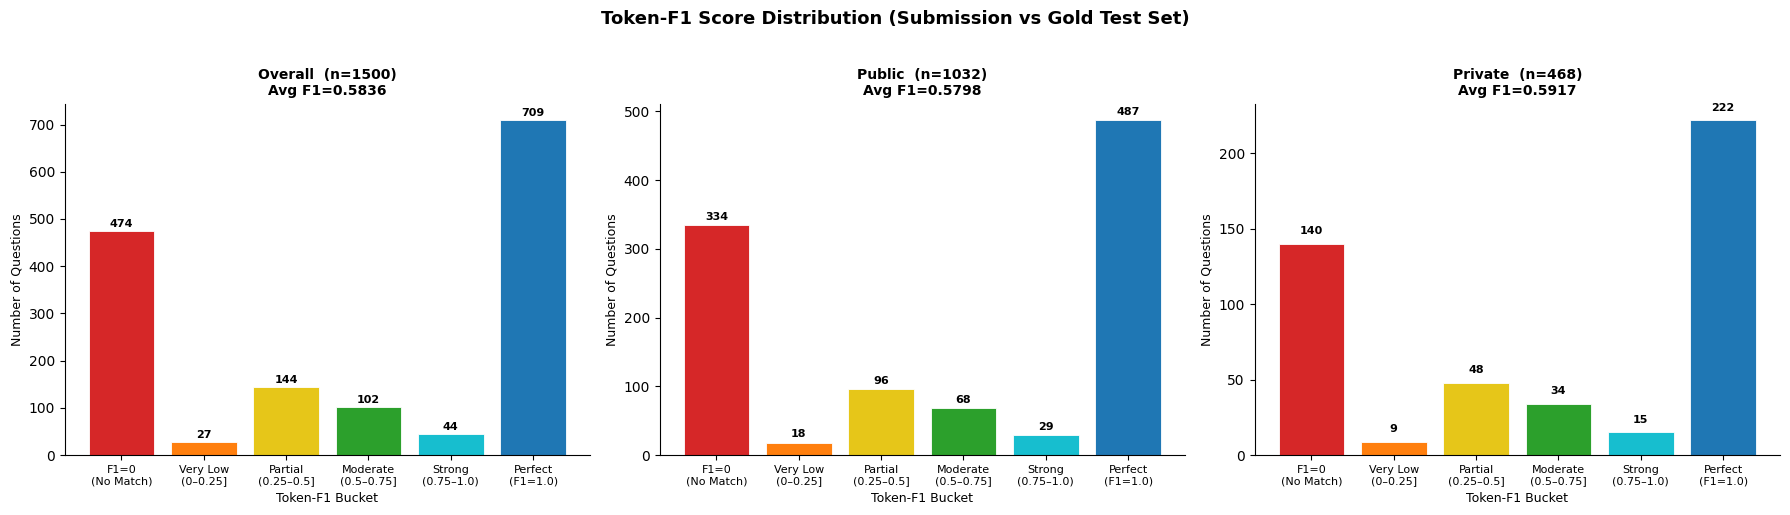

Saved: f1_distribution.png

Confusion matrix total count: 1500 (expected 1500)


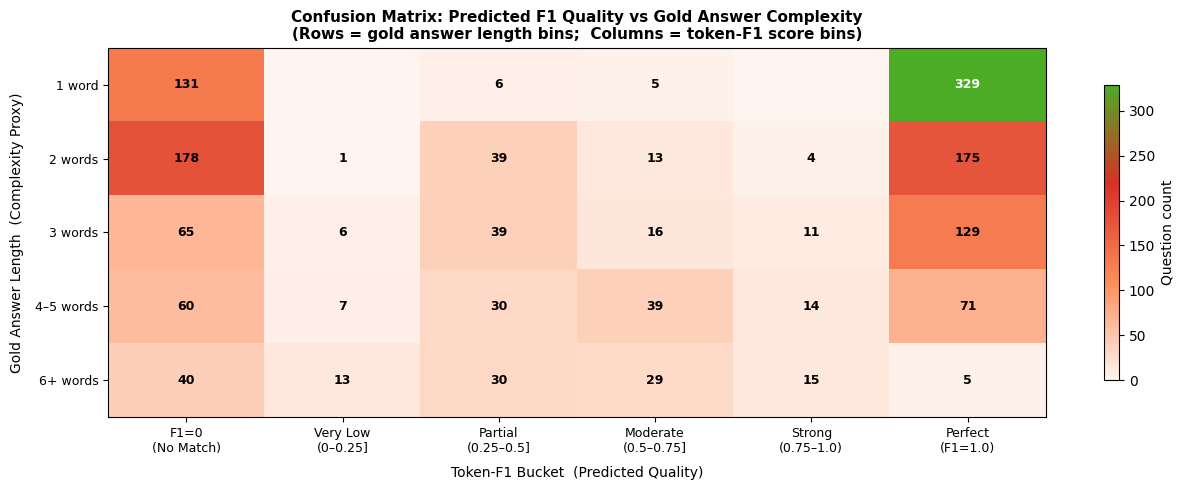

Saved: confusion_matrix.png


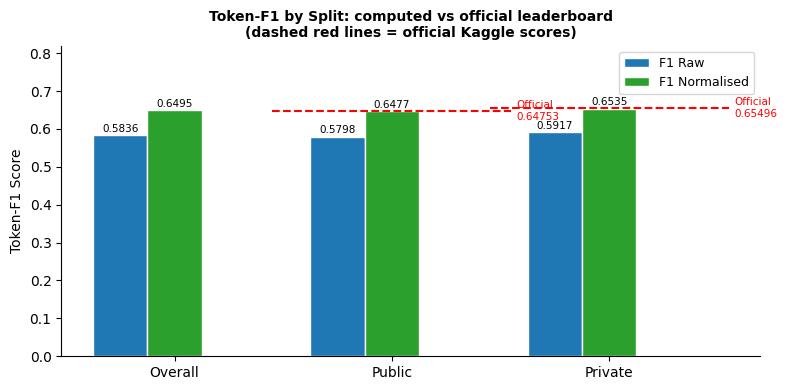

Saved: f1_by_split.png

── Sample: Perfect matches (F1 = 1.0) ──
  Q: ব্রিটিশ আমলে ব্যাঙ্কশাল কোর্ট কী নামে পরিচিত ছিল?
     Pred: স্মল মোজেস কোর্ট।  |  Gold: স্মল মোজেস কোর্ট।

  Q: আফরোজা পারভীন কবে বাংলা একাডেমি পুরস্কার অর্জন করেন?
     Pred: ২০২৩।  |  Gold: ২০২৩।

  Q: আব্রাহাম টমাস কোন দেশের অতিক্ষুদ্র শল্যচিকিৎসা বিশেষজ্ঞ?
     Pred: ভারত।  |  Gold: ভারত।

  Q: নাইট কোর্ট রিভাইভাল সিরিজের প্রথম সিজন কবে প্রিমিয়ার হয়েছিল?
     Pred: ১৭ জানুয়ারী, ২০২৩।  |  Gold: ১৭ জানুয়ারী, ২০২৩।

  Q: রুমি নাকামুরা কোন সালে গডার্ড স্পেস ফ্লাইট সেন্টারে যোগদান করেন?
     Pred: ১৯৯১।  |  Gold: ১৯৯১।

  Q: নবীনগর পশ্চিম ইউনিয়নের অন্তর্গত মহিলা মাদ্রসাটি কোন লিঙ্গের জন্য উদ্দ
     Pred: মহিলা।  |  Gold: মহিলা।

── Sample: No matches (F1 = 0.0) ──
  Q: ম্যাক্স ব্যারনের বন্ধুরা তাকে কেন প্রায়ই ঠাট্টা-বিদ্রুপ করে?
     Pred: নীতি।  |  Gold: তার প্রাথমিক চরিত্র।

  Q: কে জুতা বানানোর আধুনিক যন্ত্র তৈরি করেন?
     Pred: আন্তোনিও ফ্লুক্সা।  |  Gold: লেম্যান আর. ব্লেক।

  Q: জরায়ুর সাথে সম্পর্কিত মু

In [2]:
# === Cell 19 — Post-competition evaluation against the gold test set ===
# Added after the competition closed once official gold answers became available.
# Replicates the competition's token-level F1 metric and visualises performance
# across three complementary views:
#   Plot 1 — F1 score distribution bar chart (overall, public, private splits)
#   Plot 2 — Confusion matrix heatmap: predicted F1 quality × gold answer complexity
#   Plot 3 — Computed vs official leaderboard scores side-by-side
import re
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Paths (update if running outside the Kaggle environment) ─────────────────
GOLD_PATH = "/kaggle/input/datasets/spartacus00/test-answer/Are You Sure LLM Is Enough - Gold Set.csv"
SUB_PATH  = "/kaggle/working/submission.csv"

gold_df = pd.read_csv(GOLD_PATH)   # columns: index, question, answer, Usage
sub_df  = pd.read_csv(SUB_PATH)    # columns: index, answer

# Include "question" so the sample-inspection section shows actual question text.
merged = pd.merge(
    sub_df,
    gold_df[["index", "question", "answer", "Usage"]],
    on="index",
    suffixes=("_pred", "_gold"),
)
print(f"Merged rows: {len(merged)}  "
      f"(Public: {(merged['Usage'] == 'Public').sum()}, "
      f"Private: {(merged['Usage'] == 'Private').sum()})")

# ── Token-F1 helper functions (self-contained; mirrors Cell 14) ───────────────
def _toks_raw(s):
    return str(s).split()

def _toks_norm(s):
    s = re.sub(r'[।.,;:!?"\'`()\[\]{}\-\u2013\u2014]+', " ", str(s))
    return s.split()

def _f1(pt, tt):
    if not pt or not tt:
        return 0.0
    a, b = collections.Counter(pt), collections.Counter(tt)
    common = sum((a & b).values())
    if not common:
        return 0.0
    p = common / len(pt)
    r = common / len(tt)
    return 2 * p * r / (p + r)

def token_f1(pred, truth):
    """Token-level F1 on raw whitespace-split tokens."""
    return _f1(_toks_raw(pred), _toks_raw(truth))

def token_f1_norm(pred, truth):
    """Token-level F1 with punctuation stripped (SQuAD-style normalisation)."""
    return _f1(_toks_norm(pred), _toks_norm(truth))

merged["f1_raw"]  = merged.apply(lambda r: token_f1(r["answer_pred"],      r["answer_gold"]), axis=1)
merged["f1_norm"] = merged.apply(lambda r: token_f1_norm(r["answer_pred"], r["answer_gold"]), axis=1)

# ── Summary statistics ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("OFFICIAL LEADERBOARD  \u2192  Private: 0.65496  |  Public: 0.64753")
print("=" * 60)
for label, df in [("Overall", merged),
                  ("Public",  merged[merged["Usage"] == "Public"]),
                  ("Private", merged[merged["Usage"] == "Private"])]:
    print(f"\n{label} (n={len(df)}):")
    print(f"  F1 Raw  : {df['f1_raw'].mean():.5f}  \xb1{df['f1_raw'].std():.5f}")
    print(f"  F1 Norm : {df['f1_norm'].mean():.5f}  \xb1{df['f1_norm'].std():.5f}")
    print(f"  Perfect (F1=1.0) : {(df['f1_raw'] == 1.0).sum():4d}  ({(df['f1_raw'] == 1.0).mean():.1%})")
    print(f"  Zero    (F1=0.0) : {(df['f1_raw'] == 0.0).sum():4d}  ({(df['f1_raw'] == 0.0).mean():.1%})")
    print(f"  F1 > 0.5         : {(df['f1_raw'] >  0.5).sum():4d}  ({(df['f1_raw'] >  0.5).mean():.1%})")

# ── F1 distribution (bucketed) ────────────────────────────────────────────────
exact_zero   = (merged["f1_raw"] == 0.0).sum()
partial_vlow = ((merged["f1_raw"] > 0)    & (merged["f1_raw"] <= 0.25)).sum()
partial_low  = ((merged["f1_raw"] > 0.25) & (merged["f1_raw"] <= 0.50)).sum()
partial_mid  = ((merged["f1_raw"] > 0.50) & (merged["f1_raw"] <= 0.75)).sum()
strong       = ((merged["f1_raw"] > 0.75) & (merged["f1_raw"] <  1.00)).sum()
perfect      = (merged["f1_raw"] == 1.0).sum()

print("\n\u2500\u2500 Token-F1 Bucket Distribution \u2500\u2500")
for lbl, cnt in [
    ("F1 = 0.00  (No Match)",        exact_zero),
    ("F1 (0.00, 0.25]  (Very Low)",  partial_vlow),
    ("F1 (0.25, 0.50]  (Partial)",   partial_low),
    ("F1 (0.50, 0.75]  (Moderate)",  partial_mid),
    ("F1 (0.75, 1.00)  (Strong)",    strong),
    ("F1 = 1.00  (Perfect Match)",   perfect),
]:
    print(f"  {lbl:40s}  {cnt:4d}  ({cnt / len(merged):.1%})")

# ─────────────────────────────────────────────────────────────────────────────
# Confusion Matrix — token-F1 bins vs gold answer length bins
# Rows  = gold answer word-count bins (complexity proxy: shorter = easier to match exactly).
# Cols  = token-F1 score bins (predicted quality).
# Interpretation: cells on the rightmost column (Perfect) and top row (1-word gold)
# should be dense if the model handles short factoid answers well.
#
# FIX: previous BINS = [0, 0.01, 0.25, ...] with include_lowest=False excluded
# f1 == 0.0 from every bin (pd.cut bins are right-closed by default, so the
# first interval (0, 0.01] does not contain 0). This silently dropped all
# zero-F1 rows from the crosstab, causing the matrix to sum to 1026 instead
# of 1500. Shifting the first two edges to -0.01 and 0.0 fixes this: the
# first interval becomes (-0.01, 0.0], which correctly captures f1 == 0.
# ─────────────────────────────────────────────────────────────────────────────
BINS   = [-0.01, 0.0, 0.25, 0.50, 0.75, 0.99, 1.01]
LABELS = [
    "F1=0\n(No Match)", "Very Low\n(0\u20130.25]", "Partial\n(0.25\u20130.5]",
    "Moderate\n(0.5\u20130.75]", "Strong\n(0.75\u20131.0)", "Perfect\n(F1=1.0)",
]

merged["f1_bin"] = pd.cut(merged["f1_raw"], bins=BINS, labels=LABELS, include_lowest=False)

# Sanity check: every row must now fall into exactly one bin.
n_unbinned = merged["f1_bin"].isna().sum()
if n_unbinned:
    print(f"\n⚠ WARNING: {n_unbinned} rows still unbinned — check f1_raw range.")
else:
    print(f"\n✓ All {len(merged)} rows successfully binned (no NaNs).")

gold_len = merged["answer_gold"].astype(str).str.split().apply(len)
merged["gold_len_bin"] = pd.cut(
    gold_len,
    bins=[0, 1, 2, 3, 5, 100],
    labels=["1 word", "2 words", "3 words", "4\u20135 words", "6+ words"],
)

# ── Plot 1: F1 distribution bar chart by split ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
palette = ["#d62728", "#ff7f0e", "#e6c619", "#2ca02c", "#17becf", "#1f77b4"]

for ax, (split, df) in zip(axes, [
    ("Overall", merged),
    ("Public",  merged[merged["Usage"] == "Public"]),
    ("Private", merged[merged["Usage"] == "Private"]),
]):
    counts = df["f1_bin"].value_counts().reindex(LABELS, fill_value=0)
    bars   = ax.bar(range(len(LABELS)), counts.values, color=palette, edgecolor="white", linewidth=0.6)
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_title(f"{split}  (n={len(df)})\nAvg F1={df['f1_raw'].mean():.4f}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Number of Questions", fontsize=9)
    ax.set_xlabel("Token-F1 Bucket", fontsize=9)
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(cnt), ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Token-F1 Score Distribution (Submission vs Gold Test Set)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("f1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: f1_distribution.png")

# ── Plot 2: Confusion matrix heatmap — F1 quality bin × gold answer length ──────
cm_data = pd.crosstab(merged["gold_len_bin"], merged["f1_bin"])
cm_data = cm_data.reindex(columns=LABELS, fill_value=0)

# Sanity check: row totals must sum to 1500 across the full matrix.
total_in_matrix = cm_data.values.sum()
print(f"\nConfusion matrix total count: {total_in_matrix} (expected {len(merged)})")
assert total_in_matrix == len(merged), "Confusion matrix does not cover all rows!"

cmap = LinearSegmentedColormap.from_list("ryg", ["#fff5f0", "#fc8d59", "#d73027", "#4dac26"])

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(cm_data.values, aspect="auto", cmap=cmap, vmin=0)
plt.colorbar(im, ax=ax, label="Question count", shrink=0.8)

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontsize=9)
ax.set_yticks(range(len(cm_data.index)))
ax.set_yticklabels(cm_data.index.tolist(), fontsize=9)
ax.set_xlabel("Token-F1 Bucket  (Predicted Quality)", fontsize=10, labelpad=8)
ax.set_ylabel("Gold Answer Length  (Complexity Proxy)", fontsize=10, labelpad=8)
ax.set_title(
    "Confusion Matrix: Predicted F1 Quality vs Gold Answer Complexity\n"
    "(Rows = gold answer length bins;  Columns = token-F1 score bins)",
    fontsize=11, fontweight="bold",
)

max_val = cm_data.values.max()
for i in range(cm_data.shape[0]):
    for j in range(cm_data.shape[1]):
        val = int(cm_data.values[i, j])
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if val >= max_val * 0.6 else "black")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

# ── Plot 3: Computed vs official leaderboard F1 by split ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
splits       = ["Overall", "Public", "Private"]
f1_raw_vals  = [
    merged["f1_raw"].mean(),
    merged[merged["Usage"] == "Public"]["f1_raw"].mean(),
    merged[merged["Usage"] == "Private"]["f1_raw"].mean(),
]
f1_norm_vals = [
    merged["f1_norm"].mean(),
    merged[merged["Usage"] == "Public"]["f1_norm"].mean(),
    merged[merged["Usage"] == "Private"]["f1_norm"].mean(),
]
official = [None, 0.64753, 0.65496]   # [overall, public, private] from Kaggle leaderboard

x = np.arange(len(splits))
w = 0.25
bars1 = ax.bar(x - w, f1_raw_vals,  w, label="F1 Raw",        color="#1f77b4", edgecolor="white")
bars2 = ax.bar(x,     f1_norm_vals, w, label="F1 Normalised",  color="#2ca02c", edgecolor="white")

for idx, off_val in enumerate(official):
    if off_val is not None:
        ax.hlines(off_val, x[idx] - w * 2.2, x[idx] + w * 2.2,
                  colors="red", linewidths=1.5, linestyles="--")
        ax.text(x[idx] + w * 2.3, off_val, f"Official\n{off_val:.5f}",
                va="center", fontsize=7.5, color="red")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylim(0, 0.82)
ax.set_ylabel("Token-F1 Score")
ax.set_title(
    "Token-F1 by Split: computed vs official leaderboard\n"
    "(dashed red lines = official Kaggle scores)",
    fontsize=10, fontweight="bold",
)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("f1_by_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: f1_by_split.png")

# ── Qualitative sample inspection ────────────────────────────────────────────
print("\n\u2500\u2500 Sample: Perfect matches (F1 = 1.0) \u2500\u2500")
for _, row in merged[merged["f1_raw"] == 1.0].head(6).iterrows():
    print(f"  Q: {str(row['question'])[:70]}")
    print(f"     Pred: {row['answer_pred']}  |  Gold: {row['answer_gold']}\n")

print("\u2500\u2500 Sample: No matches (F1 = 0.0) \u2500\u2500")
for _, row in merged[merged["f1_raw"] == 0.0].head(6).iterrows():
    print(f"  Q: {str(row['question'])[:70]}")
    print(f"     Pred: {row['answer_pred']}  |  Gold: {row['answer_gold']}\n")

print("\u2500\u2500 Sample: Partial matches (0 < F1 < 1) \u2500\u2500")
for _, row in merged[(merged["f1_raw"] > 0) & (merged["f1_raw"] < 1.0)].head(6).iterrows():
    print(f"  Q: {str(row['question'])[:70]}")
    print(f"     Pred: {row['answer_pred']}  |  Gold: {row['answer_gold']}  |  F1: {row['f1_raw']:.3f}\n")

In [20]:
# === Table: Distribution of per-question token-F1 scores ===
import re, collections
import pandas as pd

GOLD_PATH = "/kaggle/input/datasets/spartacus00/test-answer/Are You Sure LLM Is Enough - Gold Set.csv"
SUB_PATH  = "/kaggle/working/submission.csv"

gold_df = pd.read_csv(GOLD_PATH)
sub_df  = pd.read_csv(SUB_PATH)
merged  = pd.merge(sub_df, gold_df[["index","answer","Usage"]], on="index", suffixes=("_pred","_gold"))

def _toks(s):
    return str(s).split()

def _f1(pt, tt):
    if not pt or not tt: return 0.0
    a, b = collections.Counter(pt), collections.Counter(tt)
    common = sum((a & b).values())
    if not common: return 0.0
    p, r = common/len(pt), common/len(tt)
    return 2*p*r/(p+r)

def token_f1(pred, truth):
    return _f1(_toks(pred), _toks(truth))

merged["f1"] = merged.apply(lambda r: token_f1(r["answer_pred"], r["answer_gold"]), axis=1)

perfect  = (merged["f1"] == 1.0).sum()
partial  = ((merged["f1"] >= 0.5) & (merged["f1"] < 1.0)).sum()
low      = ((merged["f1"] > 0)    & (merged["f1"] < 0.5)).sum()
zero     = (merged["f1"] == 0.0).sum()
total    = len(merged)

print(f"{'F1 Range':<35} {'Count':>6}  {'Percentage':>10}")
print("-" * 55)
print(f"{'Perfect  (F1 = 1.0)':<35} {perfect:>6}  {perfect/total:>9.1%}")
print(f"{'Partial  (0.5 ≤ F1 < 1.0)':<35} {partial:>6}  {partial/total:>9.1%}")
print(f"{'Low      (0 < F1 < 0.5)':<35} {low:>6}  {low/total:>9.1%}")
print(f"{'Zero     (F1 = 0.0)':<35} {zero:>6}  {zero/total:>9.1%}")
print("-" * 55)
print(f"{'Total':<35} {total:>6}  {'100.0%':>10}")

F1 Range                             Count  Percentage
-------------------------------------------------------
Perfect  (F1 = 1.0)                    709      47.3%
Partial  (0.5 ≤ F1 < 1.0)              194      12.9%
Low      (0 < F1 < 0.5)                123       8.2%
Zero     (F1 = 0.0)                    474      31.6%
-------------------------------------------------------
Total                                 1500      100.0%


In [21]:
# === Table: Predicted vs Gold Answer Length (tokens) ===
import pandas as pd

GOLD_PATH = "/kaggle/input/datasets/spartacus00/test-answer/Are You Sure LLM Is Enough - Gold Set.csv"
SUB_PATH  = "/kaggle/working/submission.csv"

gold_df = pd.read_csv(GOLD_PATH)
sub_df  = pd.read_csv(SUB_PATH)

gold_len = gold_df["answer"].astype(str).str.split().apply(len)
pred_len = sub_df["answer"].astype(str).str.split().apply(len)

print(f"{'':20} {'Median':>8} {'Mean':>8} {'Max':>6}")
print("-" * 45)
print(f"{'Gold answers':<20} {gold_len.median():>8.0f} {gold_len.mean():>8.2f} {gold_len.max():>6}")
print(f"{'Predicted answers':<20} {pred_len.median():>8.0f} {pred_len.mean():>8.2f} {pred_len.max():>6}")

                       Median     Mean    Max
---------------------------------------------
Gold answers                2     2.78     24
Predicted answers           2     2.39     12
